In [5]:
from typing import Any, Optional

from arcengine import FrameDataRaw

from arc import MyArcSession
from arc_agi import OperationMode
from arc_agi import Arcade
import logging
import numpy as np
from dotenv import load_dotenv
from PIL import Image
from sandbox import SandboxOrchestrator
from google.genai import types
from google import genai
from tools import TOOL_LIST, SYSTEM_PROMPT, TAKE_ACTION
from agent import JackAgent

load_dotenv()


PALETTE = np.array(
    [
        [0xFF, 0xFF, 0xFF],
        [0xCC, 0xCC, 0xCC],
        [0x99, 0x99, 0x99],
        [0x66, 0x66, 0x66],
        [0x33, 0x33, 0x33],
        [0x00, 0x00, 0x00],
        [0xE5, 0x3A, 0xA3],
        [0xFF, 0x7B, 0xCC],
        [0xF9, 0x3C, 0x31],
        [0x1E, 0x93, 0xFF],
        [0x88, 0xD8, 0xF1],
        [0xFF, 0xDC, 0x00],
        [0xFF, 0x85, 0x1B],
        [0x92, 0x12, 0x31],
        [0x4F, 0xCC, 0x30],
        [0xA3, 0x56, 0xD6],
    ],
    dtype=np.uint8,
)


def render_frame(frame: np.ndarray) -> Image.Image:
    rgb = PALETTE[np.clip(np.asarray(frame, dtype=np.uint8), 0, 15)]
    return Image.fromarray(rgb).resize((512, 512), Image.NEAREST)


logger = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s %(message)s", datefmt="%H:%M:%S"
)


def current_state_prompt(obs: FrameDataRaw) -> str:
    return f"""Currently playing game: {obs.game_id}. On level #{obs.levels_completed} out of #{obs.win_levels}.

"""


def starting_state_prompt(obs: FrameDataRaw) -> str:
    res = f"""Starting the following game: {obs.game_id}

"""

    return (
        f"New game started. Initial state:\n{json.dumps(obs, indent=2)}\n\n"
        f"The full grid is in /home/agent/state.json. "
        f"Start by calling render_board to see the board, then take actions to explore."
    )

In [6]:

arcade = Arcade(operation_mode=OperationMode("normal"))
scorecard_id: str = arcade.open_scorecard(tags=["jackagent"])
arc_session = MyArcSession(
    game_id=["ls20", "ft09"][0], arcade=arcade, scorecard_id=scorecard_id
)
sbx = SandboxOrchestrator()
print(sbx.bash("echo sandbox ready"))

agent = JackAgent(sbx=sbx, arc_session=arc_session)


agent.contents = []

2026-04-13 01:58:14 | INFO | Successfully fetched 25 environment(s) from API


01:58:14 Successfully fetched 25 environment(s) from API


2026-04-13 01:58:14 | INFO | Created new scorecard: 0ebb7676-59eb-4d32-8cad-3901e0ab4f01


01:58:14 Created new scorecard: 0ebb7676-59eb-4d32-8cad-3901e0ab4f01


2026-04-13 01:58:14 | INFO | Successfully fetched metadata for game ls20


...

2026-04-13 01:58:14 | INFO | Recording to recordings/0ebb7676-59eb-4d32-8cad-3901e0ab4f01/ls20-9607627b-71310287-ed07-48b3-9c18-f4644e18da6d.jsonl


01:58:14 Recording to recordings/0ebb7676-59eb-4d32-8cad-3901e0ab4f01/ls20-9607627b-71310287-ed07-48b3-9c18-f4644e18da6d.jsonl


2026-04-13 01:58:14 | INFO | Successfully loaded game class Ls20 from environment_files/ls20/9607627b/ls20.py


01:58:14 Successfully loaded game class Ls20 from environment_files/ls20/9607627b/ls20.py


sandbox ready


01:58:20 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"


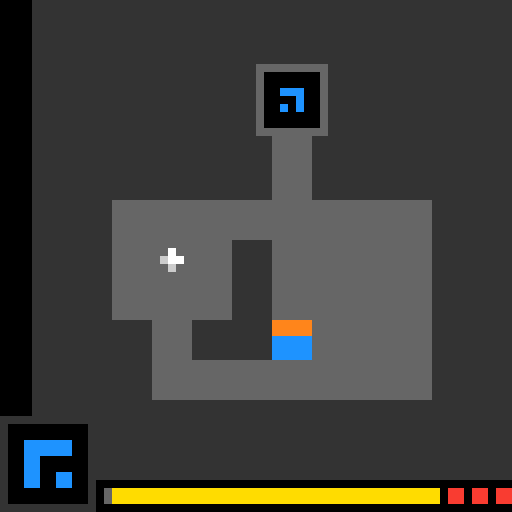

01:58:21 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"


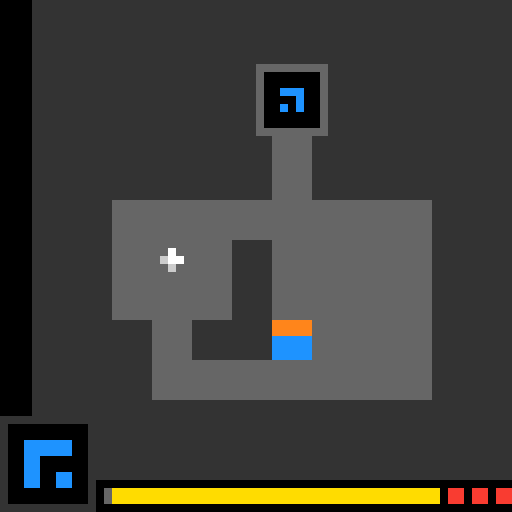

01:58:23 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"


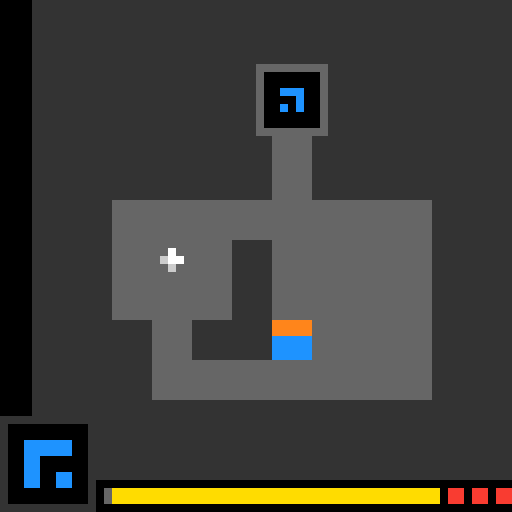

01:58:24 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"


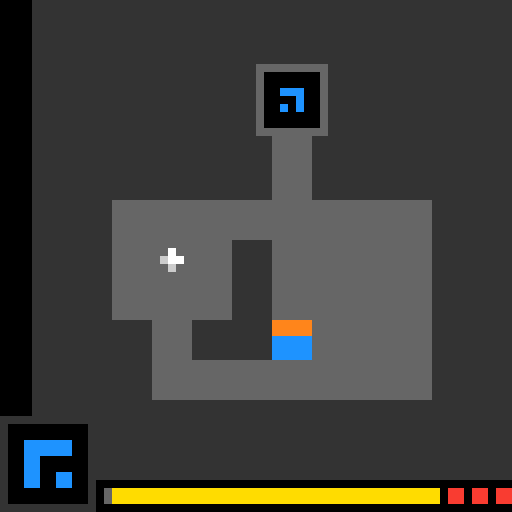

01:58:26 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"


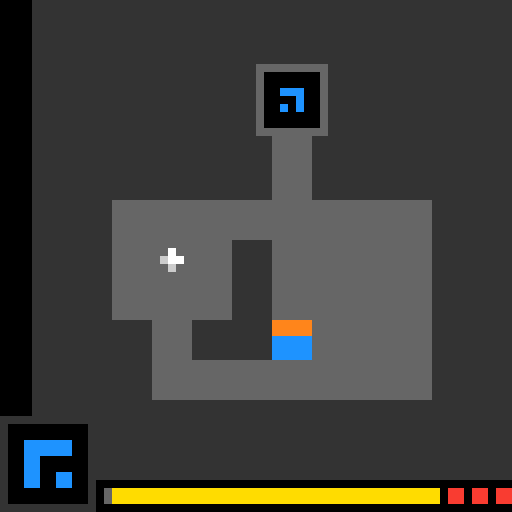

01:58:27 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"


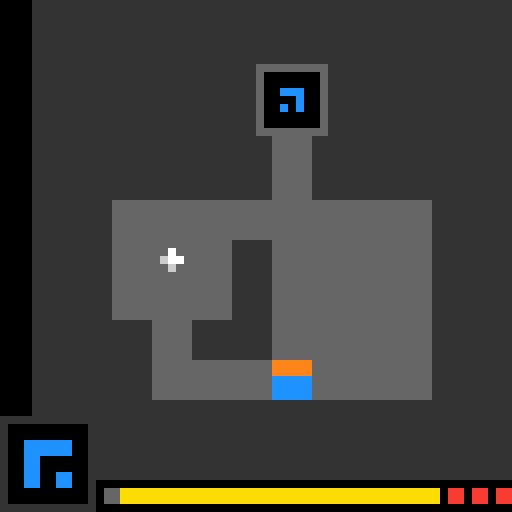

01:58:28 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"


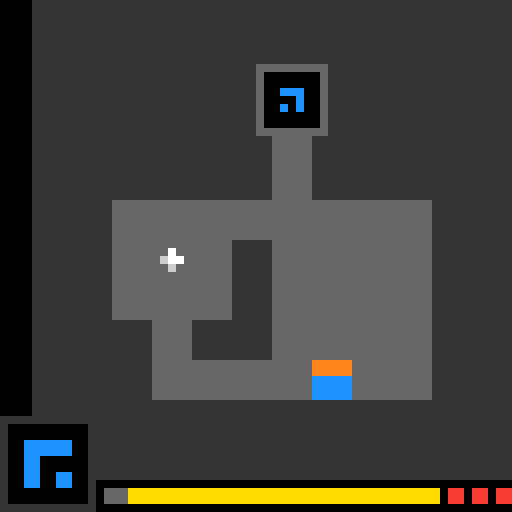

01:58:30 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"


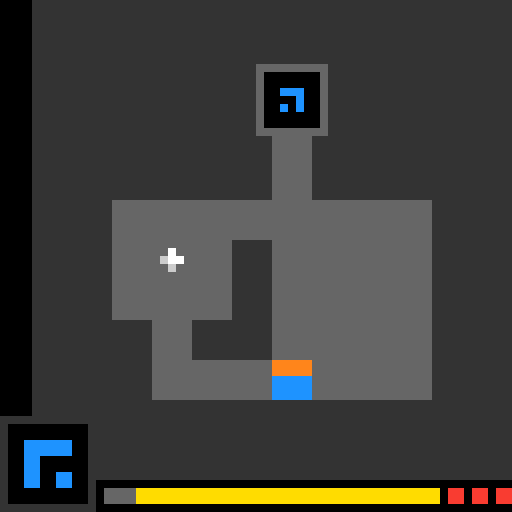

01:58:31 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"


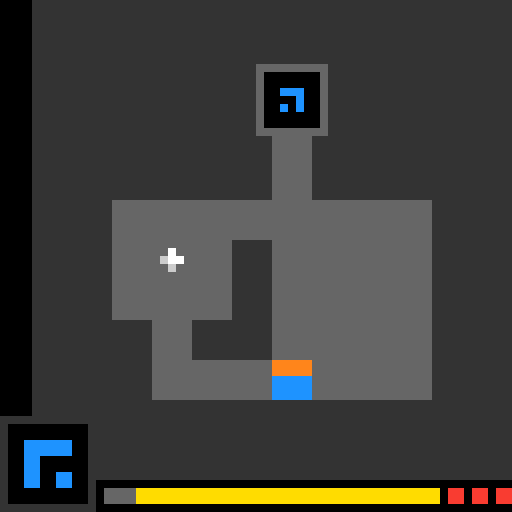

01:58:32 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"


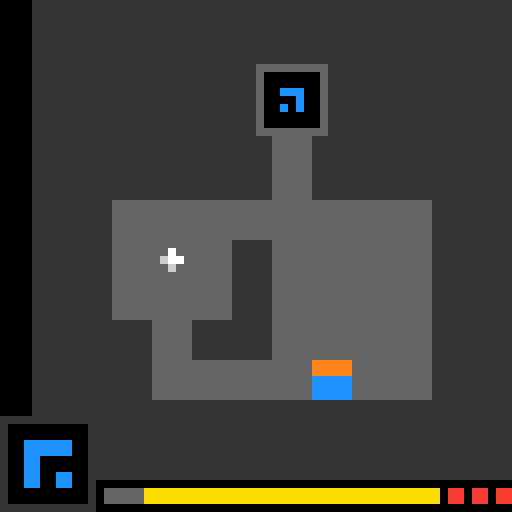

In [ ]:
agent.contents = [
    types.Content(role="user", parts=[types.Part(
        text=f"This is the current board. {arc_session.obs}")])
]

agent.contents.append(types.Content(role="user", parts=[
                      types.Part(text="solve quickly")]))

for _ in range(20):
    agent.generate_response()
    display(render_frame(agent.arc_session.obs.frame[-1]))

In [9]:
agent.contents

[Content(
   parts=[
     Part(
       text="""This is the current board. {
   "game_id": "ls20-9607627b",
   "state": "NOT_FINISHED",
   "levels_completed": 0,
   "win_levels": 7,
   "action_input": {
     "id": 0,
     "data": {},
     "reasoning": null
   },
   "guid": "71310287-ed07-48b3-9c18-f4644e18da6d",
   "full_reset": true,
   "available_actions": [
     1,
     2,
     3,
     4
   ]
 }"""
     ),
   ],
   role='user'
 ),
 Content(
   parts=[
     Part(
       text='solve quickly'
     ),
   ],
   role='user'
 ),
 Content(
   parts=[
     Part(
       function_call=FunctionCall(
         args={
           'action': 'ACTION1'
         },
         id='dxg9ruyp',
         name='take_action'
       ),
       thought_signature=b'\x124\n2\x01\xbe>\xf6\xfb\xec\x8e~\xfd\x10\xf3\xf3e\xd5\xc5+\x92\xcd\x1b@\xc9\xd5\x9f\x9ft\xd4\x10\xe8\xed\xb2\x9c\xf5(o\xad\x831\xaf!\xe8s_\x16\xc5\xbc\xc9\xc5JTL'
     ),
   ],
   role='model'
 ),
 Content(
   parts=[
     Part(
       function_response